In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

#Normal Distribution

mu = 0.0
sigma = 1.0

def normal_pdf(x, mu, sigma): #計算某個點的高度 (PDF)
    return (1.0 / np.sqrt(2*np.pi*sigma**2)) * \
           np.exp(- (x - mu)**2 / (2*sigma**2))

print("p(0) =", normal_pdf(0, mu, sigma))
print("p(2) =", normal_pdf(2, mu, sigma))

#What if sigma become larger

sigma = 2.0
print("p() =", normal_pdf(0, mu, sigma))

p(0) = 0.3989422804014327
p(2) = 0.05399096651318806
p() = 0.19947114020071635


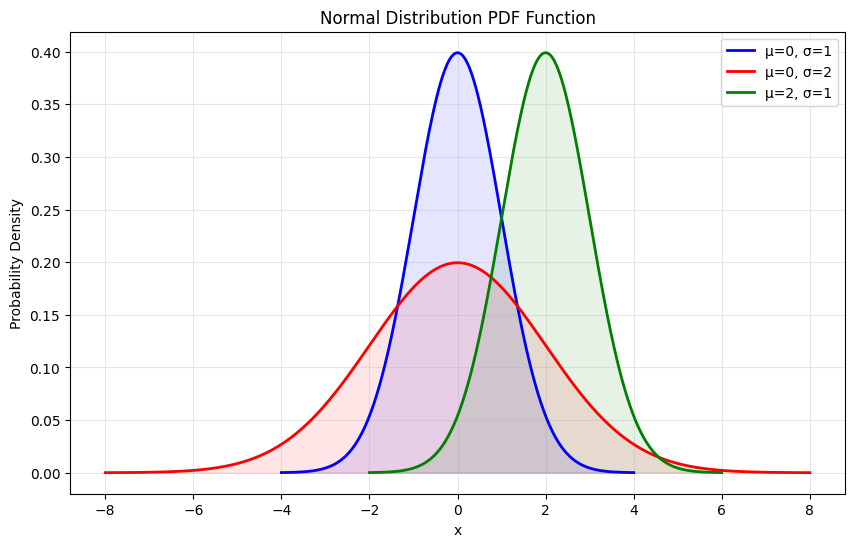

In [3]:
# 了解，你希望將「繪圖」這件事也封裝成一個函式（Function），這樣你只需要輸入不同的 $\mu$ 和 $\sigma$，它就能自動幫你畫出對應的曲線。下面我整理了一個完整的 Python 寫法，包含計算 PDF 的數學函式，以及一個專門用來繪製曲線的繪圖函式：Pythonimport numpy as np

# 1. 數學函式：計算某個點的高度 (PDF)
def normal_pdf(x, mu, sigma):
    return (1.0 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(- (x - mu)**2 / (2 * sigma**2))

# 2. 繪圖函式：傳入參數，直接畫出整條曲線
def plot_gaussian(mu, sigma, color='blue', label=None):
    # 自動根據 sigma 決定 x 軸的範圍（通常正負 4 倍標準差就能涵蓋 99.9% 的曲線）
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
    y = normal_pdf(x, mu, sigma)

    if label is None:
        label = f'μ={mu}, σ={sigma}'

    plt.plot(x, y, label=label, color=color, linewidth=2)
    plt.fill_between(x, y, alpha=0.1, color=color) # 幫曲線下方塗上淡淡的顏色

# --- 使用範例 ---
plt.figure(figsize=(10, 6))

# 你可以像這樣簡單地呼叫函式來比較不同的曲線
plot_gaussian(mu=0, sigma=1, color='blue')   # 標準常態分佈
plot_gaussian(mu=0, sigma=2, color='red')    # 變異數較大（較扁平）
plot_gaussian(mu=2, sigma=1, color='green')  # 平均數移動（中心點右移）

plt.title('Normal Distribution PDF Function')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import tensorflow as tf

mu = tf.constant([2.0])
sigma = tf.constant([0.5])

epsilon = tf.random.normal(shape=[1])

z = mu + sigma * epsilon

print("mu:", mu.numpy())
print("sigma:", sigma.numpy())
print("epsilon:", epsilon.numpy())
print("z:", z.numpy())

mu: [2.]
sigma: [0.5]
epsilon: [-0.44026613]
z: [1.7798669]


In [ ]:
import tensorflow as tf

mu = tf.constant(1.0)
sigma = tf.constant(1.5)

kl_div = 0.5 * (tf.square(mu) + tf.square(sigma)
                - tf.math.log(tf.square(sigma)) - 1.0)

print("KL Divergence:", kl_div.numpy())

KL Divergence: 0.7195349


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

latent_dim = 2

# Encoder
encoder = tf.keras.Sequential([
    layers.Dense(4, activation='relu'),
    layers.Dense(latent_dim * 2)
])

# Decoder
decoder = tf.keras.Sequential([
    layers.Dense(4, activation='relu'),
    layers.Dense(6, activation='sigmoid')
])

# Sample z
def sample_z(mu, log_var):
    epsilon = tf.random.normal(shape=tf.shape(mu))
    return mu + tf.exp(0.5 * log_var) * epsilon

# Simple VAE loss
def vae_loss(x, x_hat, mu, log_var):
    recon = tf.reduce_mean(tf.square(x - x_hat))
    kl = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mu) - tf.exp(log_var))
    return recon + kl

# -----------------------------
# Synthetic Data
# -----------------------------
x = tf.constant([[1., 0., 1., 0., 1., 0.]])

# Forward pass
h = encoder(x)
mu, log_var = tf.split(h, 2, axis=1)

z = sample_z(mu, log_var)
x_hat = decoder(z)

loss = vae_loss(x, x_hat, mu, log_var)

tf.print("Input x:", x)
tf.print("Mu:", mu)
tf.print("LogVar:", log_var)
tf.print("Sampled z:", z)
tf.print("Reconstructed x_hat:", x_hat)
tf.print("Loss:", loss)

Input x: [[1 0 1 0 1 0]]
Mu: [[-0.210524961 -0.337335169]]
LogVar: [[-0.207913667 0.377949446]]
Sampled z: [[-1.25854647 0.874986231]]
Reconstructed x_hat: [[0.608773708 0.60784936 0.629973769 0.629446864 0.563533545 0.421508104]]
Loss: 0.302217185
